# Bar Path Model Testing

Predict exercise data using saved model

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from os import path
import matplotlib.pyplot as plt
import numpy as np

DATA_COLUMNS = ['AccX', 'AccY', 'AccZ', 'VelX', 'VelY', 'VelZ', 'PosX', 'PosY', 'PosZ', 'Pitch', 'Roll', 'Yaw']

### Load data and config

In [3]:
from utils import load_airtable_data, load_config, load_mongo_data

#data = load_airtable_data()
data = load_mongo_data()
config = load_config()
data.head()

,_id,Exercise_id,Counter,TimeBetweenSamples,AccX,AccY,AccZ,Pitch,Roll,Yaw,...,User_id,Date,WorkoutTime,HeartRate,EndRepTime,StartRepTime,Intensity,Reps,Weight,Notes
0,66f8a0facfd19a2dbc3643b7,AD7CECF3-FB0B-4CDD-9C74-35F26FE1C1EA,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...","[15318, 10, 10, 10, 10, 10, 10, 10, 10, 11, 9,...","[-0.004, -0.049, -0.07, -0.051, -0.004, 0.023,...","[0.046, -0.009, 0.023, -0.019, -0.02, -0.016, ...","[-0.038, -0.014, 0.016, 0.034, 0.026, 0.075, 0...","[0.671, 0.67, 0.669, 0.667, 0.665, 0.664, 0.66...","[-0.017, -0.017, -0.018, -0.017, -0.016, -0.01...","[0.006, 0.007, 0.007, 0.007, 0.006, 0.006, 0.0...",...,001325.0c0b48026b9148b781a1435ef3ae2188.0505,2024-09-29 00:36:08,34.11,"[95, 95, 95, 95, 95, 95, 95, 95, 95, 95, 95, 9...",31.30,5.13,NaN,NaN,NaN,NaN
1,66f8a1d9cfd19a2dbc3643bf,255F3E86-9C12-4CC0-A503-E65F058E5711,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...","[195017, 10, 11, 21, 0, 9, 10, 10, 10, 10, 10,...","[-0.226, -0.295, 0.029, 0.275, 0.151, -0.101, ...","[0.095, 0.135, 0.18, 0.186, 0.154, 0.197, 0.18...","[0.019, 0.012, -0.064, -0.194, -0.222, -0.203,...","[0.615, 0.613, 0.612, 0.61, 0.609, 0.608, 0.60...","[-0.182, -0.182, -0.183, -0.185, -0.187, -0.18...","[0.058, 0.059, 0.06, 0.062, 0.064, 0.064, 0.06...",...,001325.0c0b48026b9148b781a1435ef3ae2188.0505,2024-09-29 00:39:52,29.15,"[102, 102, 102, 102, 102, 102, 102, 102, 102, ...",24.72,5.47,NaN,NaN,NaN,NaN
2,66f8a2eacfd19a2dbc3643c7,F4B75458-7440-4484-88FD-ADCF4C4F34B4,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...","[244750, 10, 10, 12, 8, 10, 11, 9, 10, 9, 10, ...","[-0.454, -0.14, 0.206, 0.17, 0.146, 0.099, 0.0...","[-0.321, -0.291, -0.243, -0.207, -0.032, 0.17,...","[0.162, 0.112, 0.026, 0.013, -0.063, -0.043, -...","[0.537, 0.534, 0.531, 0.528, 0.526, 0.525, 0.5...","[-0.199, -0.199, -0.199, -0.201, -0.201, -0.20...","[0.055, 0.054, 0.053, 0.052, 0.051, 0.05, 0.04...",...,001325.0c0b48026b9148b781a1435ef3ae2188.0505,2024-09-29 00:44:25,27.75,"[92, 92, 92, 92, 92, 92, 92, 92, 92, 92, 92, 9...",22.62,6.03,NaN,NaN,NaN,NaN
3,66f8a39ccfd19a2dbc3643cf,98650F9A-F356-4563-9A0E-26FFB73C4D77,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...","[146117, 10, 10, 10, 10, 10, 12, 9, 10, 10, 10...","[-0.25, 0.027, 0.239, 0.229, 0.186, 0.156, 0.1...","[-0.278, -0.131, 0.076, 0.191, 0.213, 0.18, 0....","[-0.097, -0.134, -0.208, -0.209, -0.182, -0.07...","[0.452, 0.45, 0.449, 0.447, 0.446, 0.445, 0.44...","[-0.018, -0.02, -0.02, -0.02, -0.02, -0.019, -...","[0.004, 0.005, 0.005, 0.005, 0.004, 0.003, 0.0...",...,001325.0c0b48026b9148b781a1435ef3ae2188.0505,2024-09-29 00:47:22,30.76,"[100, 100, 100, 100, 100, 100, 100, 100, 100, ...",26.85,12.97,NaN,NaN,NaN,NaN
4,66f8a43ecfd19a2dbc3643d7,CEE08F0F-C418-4B32-88FE-81D6EB5ECC2B,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...","[122958, 10, 10, 10, 12, 8, 10, 10, 10, 11, 9,...","[0.053, 0.1, 0.188, 0.258, 0.248, 0.13, 0.027,...","[0.116, 0.012, 0.176, 0.226, 0.223, 0.21, 0.12...","[-0.122, -0.151, -0.216, -0.211, -0.13, -0.003...","[0.271, 0.268, 0.268, 0.269, 0.271, 0.273, 0.2...","[0.054, 0.054, 0.052, 0.05, 0.05, 0.05, 0.05, ...","[-0.007, -0.006, -0.004, -0.002, 0.0, 0.001, 0...",...,001325.0c0b48026b9148b781a1435ef3ae2188.0505,2024-09-29 00:50:04,39.11,"[91, 91, 91, 91, 91, 91, 91, 91, 91, 91, 91, 9...",33.16,16.02,NaN,NaN,NaN,NaN


## Test the exercise classifier on a random sample

In [4]:
EXERCISE_CLASSIFIER = 'Exercise'

### Load the latest classifier

In [5]:
from utils import load_classifier

exercise_classifier = load_classifier(EXERCISE_CLASSIFIER)

### Predict a random record and plot

Classifier type: Exercise
Prediction: [3]
Actual: Seated Cable Row


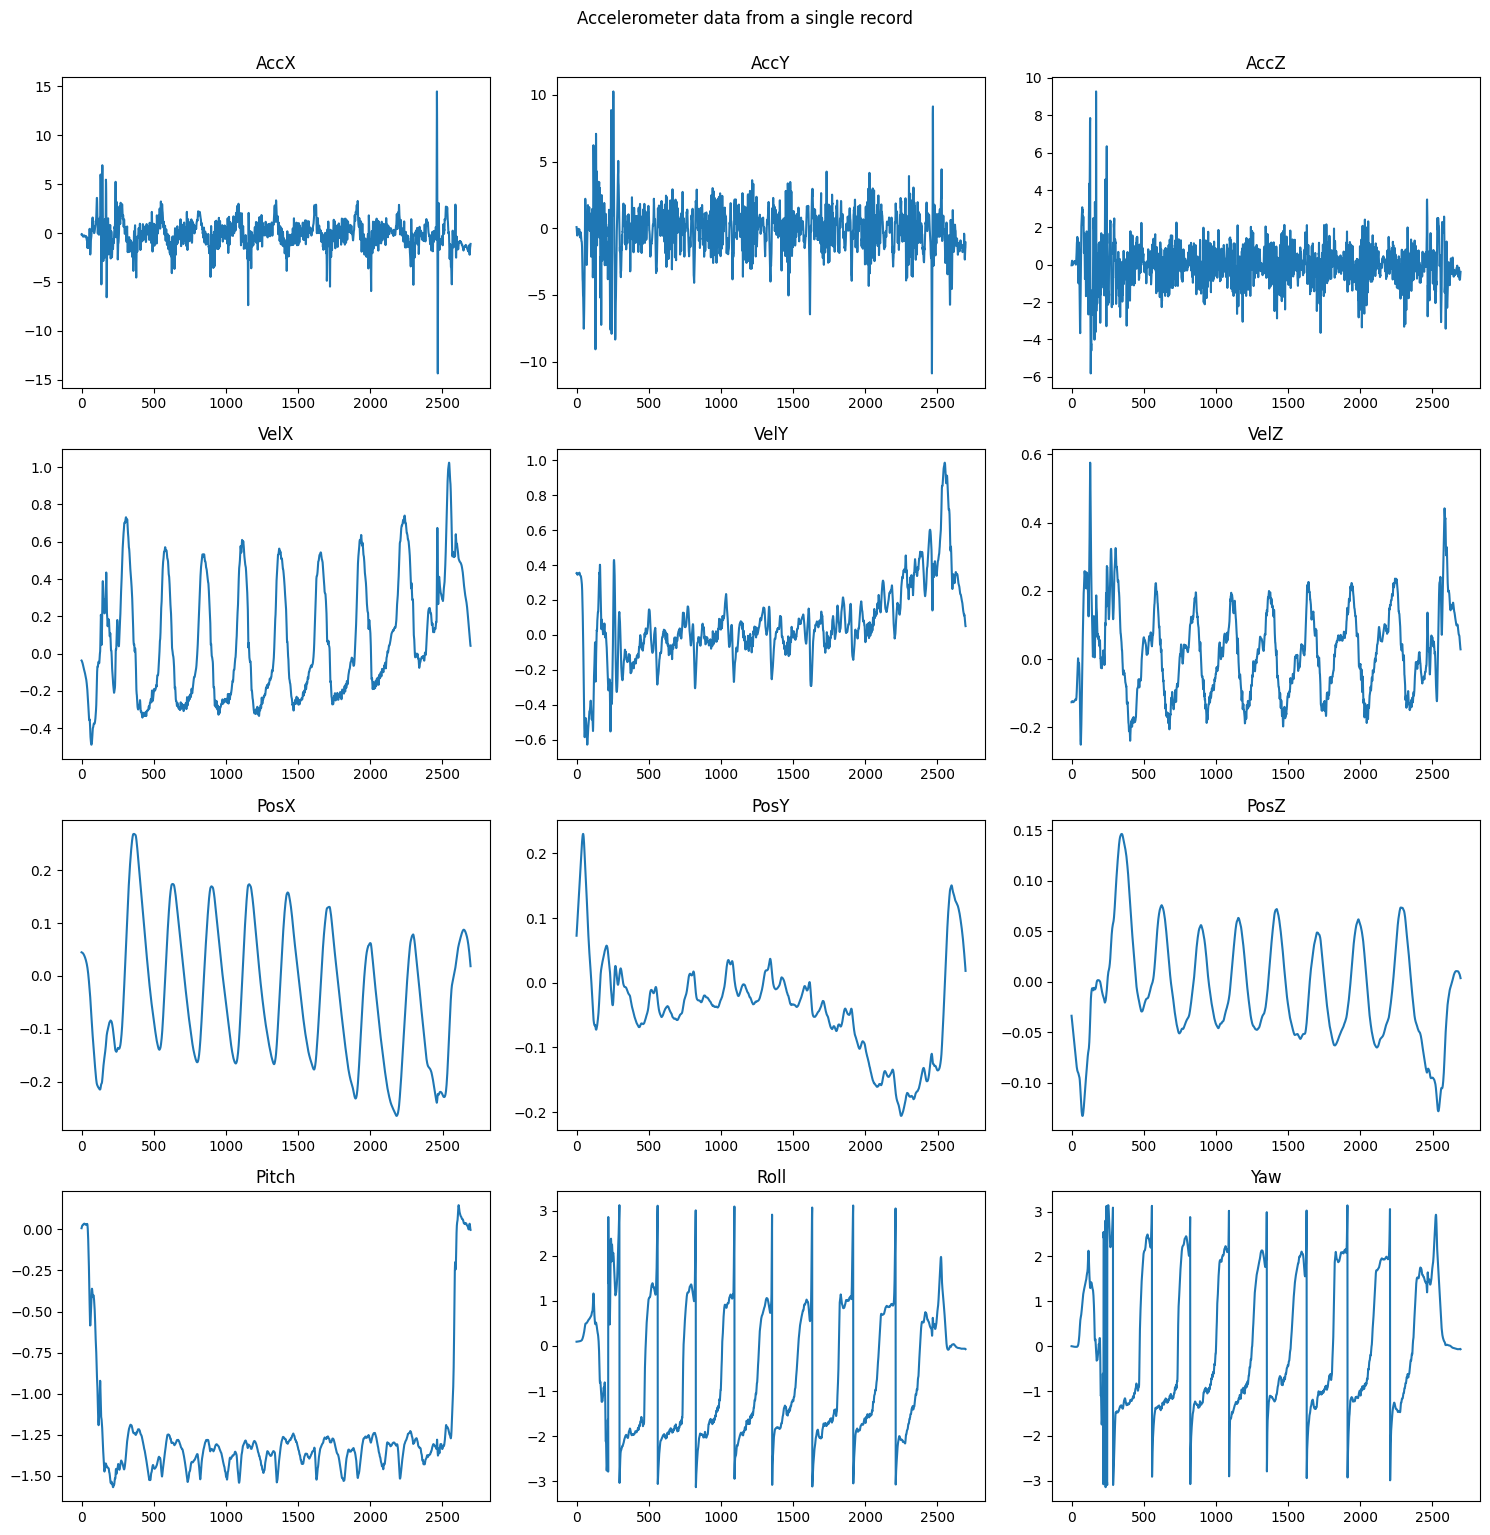

In [43]:

from preprocessing import preprocess_data, extract_features

record = data.sample(1)
record = preprocess_data(record, config['CutoffFreq'], config['SampleRate'])
features = extract_features(record)
prediction = exercise_classifier.predict(features)

print("Classifier type:", EXERCISE_CLASSIFIER)
print(f"Prediction: {prediction}")
print(f"Actual: {record['Exercise'].values[0]}")

fig, axs = plt.subplots(4, 3, figsize=(15, 15))

for i, ax in enumerate(axs.flat):
    plot_data = np.concatenate(record[DATA_COLUMNS[i]].to_numpy())
    ax.plot(plot_data)
    ax.set_title(DATA_COLUMNS[i])

plt.tight_layout()
plt.suptitle('Accelerometer data from a single record', y=1.02)
plt.show()

## Predict the rep start and stop of a random sample

In [44]:
WINDOW_CLASSIFIER = 'Window'

### Load the classifier

In [45]:
window_classifier = load_classifier(WINDOW_CLASSIFIER)

### Predict a random record

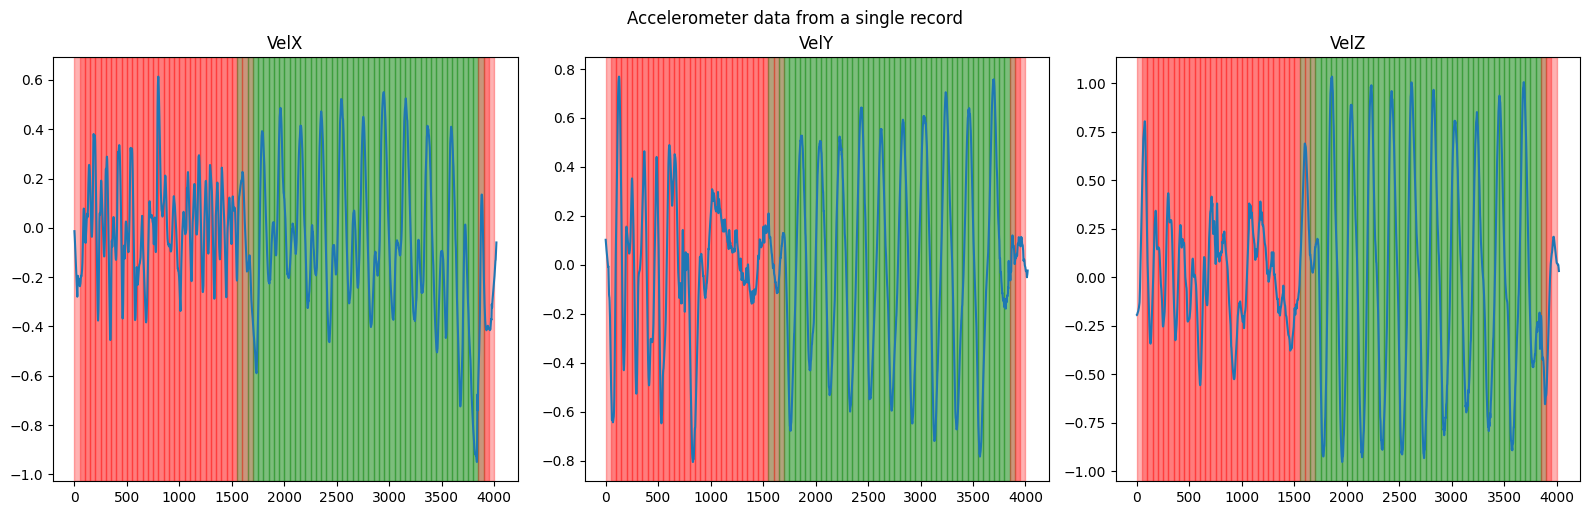

In [110]:
from preprocessing import extract_window_features

exercise_id = 'B7E5B409-4744-415A-934E-82EF8DA55486'
record = data[data['Exercise_id'] == exercise_id]

record = record.sample(1)

#record = data.sample(1)
record = preprocess_data(record, config['CutoffFreq'], config['SampleRate'])

window_features = extract_window_features(record, config['WindowLength'], config['WindowStride'])
predictions = window_classifier.predict(window_features)

fig, axs = plt.subplots(1, 3, figsize=(16, 5))

VEL_COLUMNS = ['VelX', 'VelY', 'VelZ']

for i, ax in enumerate(axs.flat):
    plot_data = np.concatenate(record[VEL_COLUMNS[i]].to_numpy())
    ax.plot(plot_data)
    ax.set_title(VEL_COLUMNS[i])
    for j in range(len(predictions)):
        ax.axvspan(j * config['WindowStride'], j * config['WindowStride'] + config['WindowLength'], color='green' if predictions[j] == 1 else 'red', alpha=0.3)

plt.tight_layout()
plt.suptitle('Accelerometer data from a single record', y=1.02)
plt.show()

### Predict start and end times

In [111]:
from postprocessing import predict_exercise_indices

start_index, end_index = predict_exercise_indices(
    predictions, config['WindowLength'], config['WindowStride'], config['MinConsqWindows'])

start_predict = start_index / config['SampleRate']
end_predict = end_index / config['SampleRate']

start_actual = float(record['StartRepTime'].values[0])
end_actual = float(record['EndRepTime'].values[0])

print(f"Predicted start: {start_predict}, actual start: {start_actual}")
print(f"Predicted end: {end_predict}, actual end: {end_actual}")

start_diff = abs(start_predict - start_actual)
end_diff = abs(end_predict - end_actual)

print(f"Start difference: {start_diff:.3f}")
print(f"End difference: {end_diff:.3f}")

Predicted start: 16.0, actual start: 15.27
Predicted end: 38.0, actual end: 38.0
Start difference: 0.730
End difference: 0.000


### Counting Reps

In [112]:
import numpy as np
from scipy.signal import butter, filtfilt, find_peaks
import matplotlib.pyplot as plt

# --- Low-pass filter function ---
def butter_lowpass_filter(data, cutoff, fs, order=4):
    nyquist = 0.5 * fs
    normal_cutoff = cutoff / nyquist
    b, a = butter(order, normal_cutoff, btype='low', analog=False)
    y = filtfilt(b, a, data)
    return y

# --- Function to detect dominant axis ---
def find_dominant_axis(vel_x, vel_y, vel_z):
    var_x, var_y, var_z = np.var(vel_x), np.var(vel_y), np.var(vel_z)
    variances = {'X': var_x, 'Y': var_y, 'Z': var_z}
    dominant_axis = max(variances, key=variances.get)
    return dominant_axis, variances

# --- Function to refine peaks to avoid double peaks ---
def refine_peaks(signal, peaks, threshold=0.5):
    refined_peaks = []
    for i in range(len(peaks)):
        if i == 0 or (peaks[i] - peaks[i-1]) > threshold:
            refined_peaks.append(peaks[i])
    return np.array(refined_peaks)

# --- Function to find troughs ---
def find_troughs(signal, peak_distance):
    inverted_signal = -signal  # Invert signal to detect troughs as peaks
    troughs, _ = find_peaks(inverted_signal, distance=peak_distance)
    return troughs

# --- Function to group peaks and troughs into reps ---
def group_peaks_and_troughs(peaks, troughs):
    reps = []
    combined = np.sort(np.concatenate((peaks, troughs)))
    for i in range(1, len(combined)):
        if combined[i] in peaks and combined[i-1] in troughs:
            reps.append((combined[i-1], combined[i]))  # Start and end of one motion
    return reps

# --- Function to process reps ---
def process_reps(pos_x, pos_y, pos_z, fs=100, cutoff=5, peak_height=0.1, peak_distance=50):
    # Step 1: Find dominant axis
    dominant_axis, variances = find_dominant_axis(pos_x, pos_y, pos_z)
    print(f"Dominant Axis: {dominant_axis}, Variances: {variances}")
    
    # Step 2: Select data and apply smoothing
    if dominant_axis == 'X':
        raw_signal = pos_x
    elif dominant_axis == 'Y':
        raw_signal = pos_y
    else:
        raw_signal = pos_z

    smooth_signal = butter_lowpass_filter(raw_signal, cutoff, fs)
    
    # Step 3: Detect peaks and troughs
    peaks, _ = find_peaks(smooth_signal, height=peak_height, distance=peak_distance)
    troughs = find_troughs(smooth_signal, peak_distance=peak_distance)
    
    # Step 4: Group peaks and troughs into reps
    reps = group_peaks_and_troughs(peaks, troughs)
    
    return smooth_signal, peaks, troughs, reps, dominant_axis

Dominant Axis: Z, Variances: {'X': 0.010989614394823021, 'Y': 0.016776364134095046, 'Z': 0.0329384976508616}


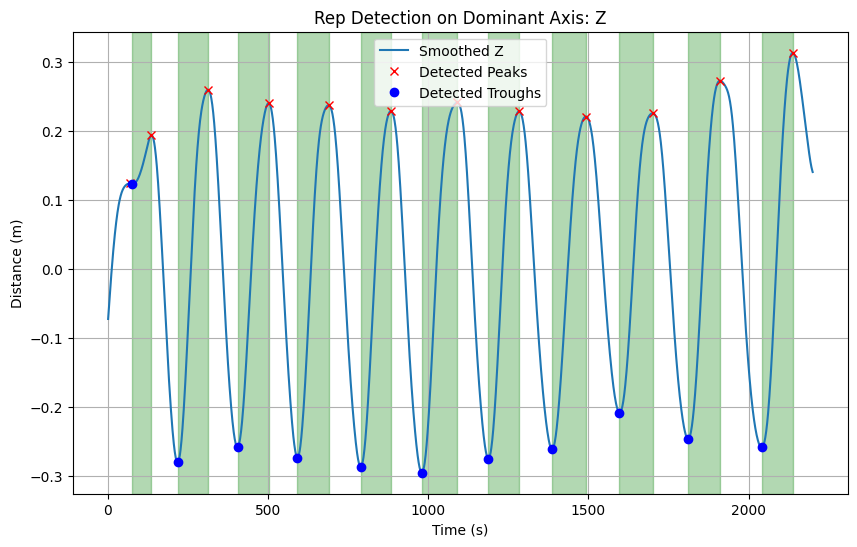

Number of reps detected: 11


In [113]:
fs = 100  # Sampling frequency
cutoff = 3  # Cutoff frequency for smoothing

# Process reps
t = np.concatenate(record['Counter'].to_numpy())
start_idx = int(start_predict * fs)
end_idx = int(end_predict * fs)
pos_x = np.concatenate(record['PosX'].to_numpy())[start_idx:end_idx]
pos_y = np.concatenate(record['PosY'].to_numpy())[start_idx:end_idx]
pos_z = np.concatenate(record['PosZ'].to_numpy())[start_idx:end_idx]


# Process reps
smooth_signal, peaks, troughs, reps, dominant_axis = process_reps(pos_x, pos_y, pos_z, fs=fs, cutoff=cutoff)

# Ensure t and smooth_signal have the same length
t = t[:len(smooth_signal)]

# Plot raw and processed data
plt.figure(figsize=(10, 6))
plt.plot(t, smooth_signal, label=f"Smoothed {dominant_axis}")
plt.plot(t[peaks], smooth_signal[peaks], "x", label="Detected Peaks", color='red')
plt.plot(t[troughs], smooth_signal[troughs], "o", label="Detected Troughs", color='blue')

for start, end in reps:
    plt.axvspan(t[start], t[end], color='green', alpha=0.3)

plt.title(f"Rep Detection on Dominant Axis: {dominant_axis}")
plt.xlabel("Time (s)")
plt.ylabel("Distance (m)")
plt.legend()
plt.grid()
plt.show()

print(f"Number of reps detected: {len(reps)}")

## Calculate start time predictions for all data

### Calculate error for each record

In [52]:
start_errors = []
end_errors = []

data = preprocess_data(data, config['CutoffFreq'], config['SampleRate'])
for i in range(len(data)):
    record = data.loc[[i]]
    window_features = extract_window_features(record, config['WindowLength'], config['WindowStride'])
    predictions = window_classifier.predict(window_features)

    start_predict_index, end_predict_index = predict_exercise_indices(
        predictions, config['WindowLength'], config['WindowStride'], config['MinConsqWindows'])
    
    start_predict = start_predict_index / config['SampleRate']
    end_predict = end_predict_index / config['SampleRate']

    start_actual = float(record['StartRepTime'].values[0])
    end_actual = float(record['EndRepTime'].values[0])
    
    start_error = abs(start_predict - start_actual)
    end_error = abs(end_predict - end_actual)
    start_errors.append(start_error)
    end_errors.append(end_error)

start_errors = np.array(start_errors)
end_errors = np.array(end_errors)

Error processing column AccX with feature Mean: 'AccX'


KeyError: 'AccX'

### Log the results

In [12]:
start_avg_error = np.mean(start_errors)
end_avg_error = np.mean(end_errors)

print(f"Average start error: {start_avg_error:.3f}")
print(f"Average end error: {end_avg_error:.3f}")

RESULTS_FOLDER = 'results'
RESULTS_FILENAME = 'results.txt'

from datetime import datetime
import os

results_file = path.join(RESULTS_FOLDER, RESULTS_FILENAME)

if not path.exists(RESULTS_FOLDER):
    os.makedirs(RESULTS_FOLDER)

with open(results_file, 'a') as f:
    f.write(f"{datetime.now()}\n")
    f.write(f"Average start error: {start_avg_error:.3f}\n")
    f.write(f"Average end error: {end_avg_error:.3f}\n")
    f.write(f"Window length: {config['WindowLength']}\n")
    f.write(f"Window stride: {config['WindowStride']}\n")
    f.write(f"Min consecutive windows: {config['MinConsqWindows']}\n\n")

Average start error: 0.308
Average end error: 0.383


### Save this notebook to a script

In [ ]:
# Convert the notebook to a script
!jupyter nbconvert --to script BarPathModelTraining.ipynb --output test_models